# 🧠 Learn ReAct Multiagent Systems — From Zero to Hero
### A step-by-step teaching notebook

---

## 📚 What You Will Learn

| Step | Concept |
|---|---|
| 1 | What is an **Agent**? |
| 2 | What is the **ReAct Pattern**? (Reason + Act) |
| 3 | What is a **Tool**? |
| 4 | Build your **first ReAct Agent** |
| 5 | What is **MessagesState**? |
| 6 | What is a **Router** (conditional edges)? |
| 7 | Build a **2-Agent system** (Researcher + Chart Generator) |
| 8 | Run it end-to-end |

---

## 🧩 The Big Picture

```
You (Human)
    │
    ▼  "Research GDP of India, USA, China and plot a bar chart"
┌─────────────────────────────────────────────────────────┐
│                  LangGraph Workflow                     │
│                                                         │
│  ┌──────────────┐   router    ┌───────────────────────┐ │
│  │  Researcher  │ ──────────▶ │   Chart Generator     │ │
│  │  (ReAct)     │ ◀────────── │   (ReAct)             │ │
│  │              │   loop?     │                       │ │
│  │ Tool: Tavily │             │ Tool: PythonREPL      │ │
│  └──────────────┘             └───────────────────────┘ │
└─────────────────────────────────────────────────────────┘
    │
    ▼  Chart PNG saved to disk
```

**Key insight**: Each agent is a loop — it thinks, calls a tool, reads the result, thinks again, until it decides it's done.

---
## 📦 Step 1 — Install Dependencies

In [ ]:
%pip install -q langchain langchain-openai langchain-community langgraph \
               langchain-experimental tavily-python python-dotenv matplotlib

---
## 🤔 Step 2 — What is an Agent?

A **regular LLM call** looks like this:
```
You → "What is 2+2?" → LLM → "4"
```
Simple. One call, one answer.

An **Agent** is different:
```
You → "Book me a flight to Paris" → Agent
                                       │
                                       ├─ thinks: "I need to search for flights"
                                       ├─ calls tool: search_flights("Paris")
                                       ├─ reads result: ["Air France $450", ...]
                                       ├─ thinks: "I found options, should I book?"
                                       ├─ calls tool: book_flight("Air France", ...)
                                       └─ "Done! Your flight is booked."
```

**An agent = LLM + Tools + a loop that keeps going until the task is done.**

---
## ⚡ Step 3 — What is the ReAct Pattern?

**ReAct = Reasoning + Acting** (a famous AI paper from 2022)

At each step the agent follows this cycle:

```
┌─────────────────────────────────────────┐
│  THOUGHT  → "I need to search for GDP" │  ← LLM thinks
│  ACTION   → call search_tool("GDP")    │  ← LLM calls a tool
│  OBSERVATION → "GDP of India is $3.5T" │  ← Tool returns result
│  THOUGHT  → "I have enough data now"   │  ← LLM thinks again
│  FINAL ANSWER → "Here are the GDPs..." │  ← LLM is done
└─────────────────────────────────────────┘
```

This cycle can repeat **many times** before the agent decides it has enough information.

LangChain's `create_react_agent()` implements this pattern automatically — you just give it tools and a system prompt.

---
## 🔧 Step 4 — Imports & Setup

In [1]:
import operator
import uuid
import os
from typing import Annotated, Sequence
from typing_extensions import TypedDict

from dotenv import load_dotenv
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.runnables import RunnableConfig
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import create_react_agent
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.checkpoint.memory import MemorySaver
from langchain_experimental.utilities import PythonREPL

load_dotenv(override=True)
print("✅ All imports successful")

C:\Users\E264598\AppData\Local\Temp\ipykernel_6016\1092098010.py:10: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults


✅ All imports successful


C:\Users\E264598\AppData\Local\Temp\ipykernel_6016\1092098010.py:16: DeprecationWarning: `langchain-experimental` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-experimental/issues/87 for details.
  from langchain_experimental.utilities import PythonREPL


---
## 🌐 Step 5 — What is a Tool?

A **Tool** is a function the LLM can call to interact with the real world.
The LLM **cannot** browse the internet or run code on its own — tools give it those abilities.

We use **two tools** in this system:

| Tool | What it does |
|---|---|
| `TavilySearchResults` | Searches the internet and returns real, live results |
| `python_repl_tool` | Executes arbitrary Python code and returns the output |

The `@tool` decorator turns any Python function into a LangChain tool.
The **docstring** is what the LLM reads to understand when and how to use the tool.

In [2]:
# ── Tool 1: Tavily Web Search ────────────────────────────────────────────────
# TavilySearch connects to the internet and returns real search results.
# max_results=3 means it fetches the top 3 results per query.
# search_depth="advanced" gives richer content extraction.

tavily_tool = TavilySearchResults(
    max_results=3,
    search_depth="advanced"
)

print("✅ Tavily search tool ready")
print(f"   Tool name : {tavily_tool.name}")
print(f"   Tool desc : {tavily_tool.description[:80]} …")

✅ Tavily search tool ready
   Tool name : tavily_search_results_json
   Tool desc : A search engine optimized for comprehensive, accurate, and trusted results. Usef …


C:\Users\E264598\AppData\Local\Temp\ipykernel_6016\875117187.py:6: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_tool = TavilySearchResults(


In [3]:
# ── Tool 2: Python REPL ──────────────────────────────────────────────────────
# PythonREPL is a Python interpreter that can execute code strings.
# We wrap it in a @tool so the LLM can call it like a function.

python_repl = PythonREPL()   # the actual Python interpreter

@tool
def python_repl_tool(
    code: Annotated[str, "Pure python code only. You MUST save charts as image files."]
):
    """
    Executes Python code in a live interpreter.
    Charts MUST be saved to disk using plt.savefig() and the file path must be printed.
    """
    try:
        result = python_repl.run(code)
    except BaseException as e:
        return f"Execution failed: {repr(e)}"
    return f"Python executed successfully.\n{result}"

print("✅ Python REPL tool ready")
print(f"   Tool name : {python_repl_tool.name}")
print(f"   Tool args : {list(python_repl_tool.args.keys())}")

✅ Python REPL tool ready
   Tool name : python_repl_tool
   Tool args : ['code']


---
## 🤖 Step 6 — LLM Setup

We use **OpenAI GPT-4o-mini** as the brain for both agents.
`temperature=0` means deterministic output (no randomness) — good for structured tasks.

In [4]:
llm = ChatOpenAI(
    model="gpt-4o-mini",
    api_key=os.getenv("OPENAI_API_KEY"),
    temperature=0      # deterministic: same input → same output
)

print("✅ LLM ready:", llm.model_name)

✅ LLM ready: gpt-4o-mini


---
## 💬 Step 7 — What is MessagesState?

In the `multiagent_sms` notebook, we used a **TypedDict** state with named fields:
```python
class ResearchState(TypedDict):
    topic: str
    research_notes: str
    report: str
    ...
```

In **this system**, we use `MessagesState` instead — a special LangGraph state that holds a **list of chat messages**:
```python
# MessagesState is roughly equivalent to:
class MessagesState(TypedDict):
    messages: Annotated[list[BaseMessage], operator.add]   # messages accumulate
```

**Why messages?**
- Every piece of information (user request, agent thoughts, tool results) is a **message**
- All agents share the same message list — each agent can see everything that happened before
- `operator.add` means messages are **appended**, never overwritten

```
messages list grows over time:
[
  HumanMessage("Research GDP..."),         ← your original question
  AIMessage("I'll search for this..."),    ← researcher thinking
  ToolMessage("GDP India $3.5T..."),        ← tavily result
  AIMessage("Label: India\nValue: 3.5"),   ← researcher final answer
  AIMessage("I'll create the chart..."),   ← chart agent thinking
  ToolMessage("Chart saved to chart.png"), ← repl result
  AIMessage("FINAL ANSWER"),               ← chart agent done
]
```

---
## 🏗️ Step 8 — Build Agent 1: The Researcher

The Researcher's job:
1. Read the user's question
2. Search the web using Tavily
3. Return structured numeric data (Label/Value format) ready for charting

The **system prompt** is critical — it tells the LLM **exactly** what role it plays and what output format is expected.

In [5]:
# ── Helper: shared system prompt prefix ────────────────────────────────────
def make_system_prompt(suffix: str) -> str:
    """Prepends a shared multi-agent preamble to any agent-specific instructions."""
    return (
        "You are part of a multi-agent system.\n"
        "Follow your role strictly.\n"
        "Do not refuse tasks.\n"
        "Do not explain limitations.\n"
        f"{suffix}"
    )


# ── Researcher System Prompt ────────────────────────────────────────────────
# This tells the LLM:
#   - It IS the researcher (role)
#   - It MUST use Tavily to search (forced tool use)
#   - It MUST output data in Label/Value format (output contract for next agent)

research_agent_system_prompt = """
You are a research agent.

Your job is to gather data needed for chart generation.

STRICT RULES:
1. Use TavilySearch to fetch real data from the internet.
2. ALWAYS extract or infer numeric values.
3. NEVER refuse due to lack of real-time access.
4. If exact values are unavailable, use best estimates.
5. DO NOT generate charts or code.

OUTPUT FORMAT (MANDATORY):
Return data in this exact structure so the chart agent can parse it:

Label: <category or x-axis value>
Value: <numeric value>
Unit: <optional unit>

Repeat for each data point. Provide at least 3 data points.
"""


# ── Create the Researcher ReAct Agent ─────────────────────────────────────
# create_react_agent() automatically builds the Thought → Act → Observe loop
# You provide: the LLM brain, the tools it can use, and its system prompt

research_agent = create_react_agent(
    llm,
    tools=[tavily_tool],                                # only has web search
    prompt=make_system_prompt(research_agent_system_prompt),
)


# ── Node wrapper function ──────────────────────────────────────────────────
# LangGraph nodes must accept state and return state.
# This thin wrapper calls the ReAct agent and updates the messages list.

def research_node(state: MessagesState) -> MessagesState:
    print("\n🔍 [Researcher] Running …")
    result = research_agent.invoke(state)   # run the full ReAct loop
    print(f"   → Done. Total messages now: {len(result['messages'])}")
    return {"messages": result["messages"]}


print("✅ Researcher agent ready")

✅ Researcher agent ready


C:\Users\E264598\AppData\Local\Temp\ipykernel_6016\2786954257.py:46: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  research_agent = create_react_agent(


---
## 🏗️ Step 9 — Build Agent 2: The Chart Generator

The Chart Generator's job:
1. Read the structured data from the Researcher's messages
2. Write Python code (matplotlib) to create a chart
3. Call `python_repl_tool` to **actually execute** that code
4. Save the chart as a PNG file
5. Reply with `FINAL ANSWER` when done — this tells the router to stop

> ⚠️ The key difference from `multiagent_sms`: here the LLM **writes the chart code itself** and runs it via the REPL tool. In `multiagent_sms`, we wrote the chart code ourselves in Python.

In [6]:
# ── Chart Generator System Prompt ──────────────────────────────────────────
# Critical instructions:
#   - MUST call the python_repl_tool (not just output code as text)
#   - MUST save chart with plt.savefig() (not plt.show())
#   - MUST end with "FINAL ANSWER" so the router knows to stop

chart_generator_system_prompt = """
You are a chart-generation agent.

Your job is to generate charts based on structured numeric data
provided by the research agent.

STRICT RULES:
1. Parse Label/Value pairs from the previous message.
2. Choose an appropriate chart type (bar, line, or pie).
3. ALWAYS call `python_repl_tool` to execute your chart code. NEVER just output code.
4. Save the chart as a PNG file using plt.savefig('chart_output.png').
5. Print the saved file path in the code.
6. Do NOT call plt.show() — only plt.savefig().
7. After the tool executes successfully, respond ONLY with:
   FINAL ANSWER
"""


# ── Create the Chart Generator ReAct Agent ────────────────────────────────
chart_agent = create_react_agent(
    llm,
    tools=[python_repl_tool],          # only has the Python REPL
    prompt=make_system_prompt(chart_generator_system_prompt),
)


# ── Node wrapper function ──────────────────────────────────────────────────
def chart_node(state: MessagesState) -> MessagesState:
    print("\n🎨 [Chart Generator] Running …")
    result = chart_agent.invoke(state)
    print(f"   → Done. Total messages now: {len(result['messages'])}")
    return {"messages": result["messages"]}


print("✅ Chart Generator agent ready")

✅ Chart Generator agent ready


C:\Users\E264598\AppData\Local\Temp\ipykernel_6016\339741192.py:26: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  chart_agent = create_react_agent(


---
## 🚦 Step 10 — The Router (Conditional Edges)

This is **the most important difference** from the linear `multiagent_sms` pipeline.

In `multiagent_sms`:
```
A → B → C → D    (always, no matter what)
```

Here, after each agent runs, a **router function** inspects the last message and decides:
- If the last message contains `"FINAL ANSWER"` → go to END (done!)
- Otherwise → send to the **other** agent (keep working)

This allows agents to **loop back** if the chart agent fails and needs more data from the researcher.

```
                    router says "continue"
Researcher ──────────────────────────────▶ Chart Generator
    ▲                                            │
    │         router says "continue"             │
    └────────────────────────────────────────────┘
                                                 │
                   router says END               │
    END ◀────────────────────────────────────────┘
         (when last message contains "FINAL ANSWER")
```

In [7]:
# ── Router Function ──────────────────────────────────────────────────────────
# This function is called AFTER each agent node completes.
# It reads the last message and decides what to do next.

def router(state: MessagesState):
    last_message = state["messages"][-1]   # look at the most recent message

    # If the agent said "FINAL ANSWER", we're done
    if "FINAL ANSWER" in last_message.content:
        print("   ✅ Router → END (FINAL ANSWER detected)")
        return END

    # Otherwise keep going (send to the next agent)
    print("   🔄 Router → continue")
    return "continue"


print("✅ Router function defined")
print()
print("How it works:")
print('  last message has "FINAL ANSWER" → END')
print('  last message does NOT           → "continue" (next agent)')

✅ Router function defined

How it works:
  last message has "FINAL ANSWER" → END
  last message does NOT           → "continue" (next agent)


---
## 🔨 Step 11 — Assemble the LangGraph

Now we wire everything together.

```
START
  │
  ▼
researcher ──(router)──▶  chart_generator
    ▲                           │
    │◀──────(router: loop)──────┤
                                │
                    (router: END)
                                │
                               END
```

`add_conditional_edges` is what makes this different from a linear pipeline:
- After `researcher` runs → call `router()` → if `"continue"` go to `chart_generator`, if `END` stop
- After `chart_generator` runs → call `router()` → if `"continue"` go back to `researcher`, if `END` stop

In [8]:
# ── Build the Graph ──────────────────────────────────────────────────────────

workflow = StateGraph(MessagesState)   # use MessagesState as our shared state

# Register the two agent nodes
workflow.add_node("researcher",      research_node)
workflow.add_node("chart_generator", chart_node)

# ── Entry point: always start with the researcher ───────────────────────────
workflow.add_edge(START, "researcher")

# ── Conditional edge from researcher ────────────────────────────────────────
# After researcher runs, call router():
#   router returns "continue" → go to chart_generator
#   router returns END        → stop
workflow.add_conditional_edges(
    "researcher",
    router,
    {"continue": "chart_generator", END: END},
)

# ── Conditional edge from chart_generator ───────────────────────────────────
# After chart_generator runs, call router():
#   router returns "continue" → go back to researcher
#   router returns END        → stop
workflow.add_conditional_edges(
    "chart_generator",
    router,
    {"continue": "researcher", END: END},
)

# ── Compile with MemorySaver (enables thread-based state persistence) ────────
# MemorySaver stores the full state per thread_id
# This allows you to continue a conversation across multiple invocations
app = workflow.compile(checkpointer=MemorySaver())

print("✅ LangGraph compiled successfully")

✅ LangGraph compiled successfully


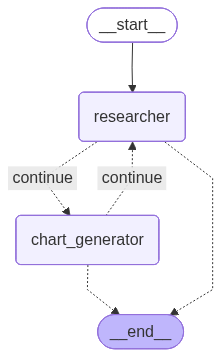

In [9]:
# ── Visualise the Graph ──────────────────────────────────────────────────────
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    print(app.get_graph().draw_ascii())

---
## ▶️ Step 12 — Run Example 1: GDP Comparison

**What will happen step by step:**
1. Your message enters as `HumanMessage` in the state
2. `researcher` runs its ReAct loop → calls Tavily → collects GDP data → outputs Label/Value pairs
3. Router checks: no `FINAL ANSWER` → sends to `chart_generator`
4. `chart_generator` runs its ReAct loop → writes matplotlib code → calls `python_repl_tool` → chart saved
5. Router checks: `FINAL ANSWER` found → END

> `recursion_limit=10` sets the maximum number of node visits to prevent infinite loops.
> `thread_id` is a unique ID for this conversation — `MemorySaver` uses it to store/retrieve state.

  Running multiagent system …

🔍 [Researcher] Running …
   → Done. Total messages now: 6
   🔄 Router → continue

🎨 [Chart Generator] Running …


Python REPL can execute arbitrary code. Use with caution.


   → Done. Total messages now: 9
   ✅ Router → END (FINAL ANSWER detected)

  ✅ Done!
  Total messages in state: 9


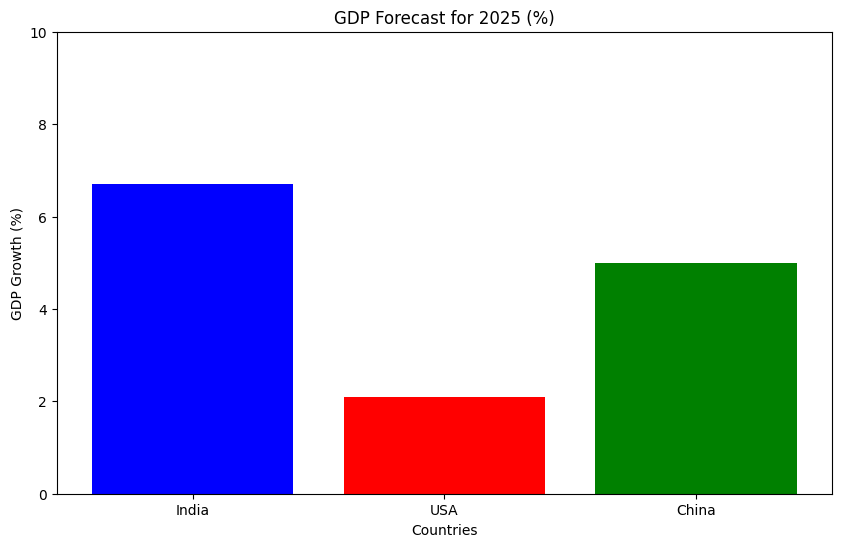

In [10]:
# ── Configuration ────────────────────────────────────────────────────────────
config = RunnableConfig(
    recursion_limit=10,                              # max 10 node visits
    configurable={"thread_id": str(uuid.uuid4())}    # unique run ID
)

# ── Input: your question as a HumanMessage ───────────────────────────────────
inputs = {
    "messages": [
        HumanMessage(
            content="Research the GDP of India, USA, and China for 2025 and compare them using a bar chart"
        )
    ]
}

print("=" * 60)
print("  Running multiagent system …")
print("=" * 60)

result = app.invoke(inputs, config=config)

print("\n" + "=" * 60)
print("  ✅ Done!")
print(f"  Total messages in state: {len(result['messages'])}")
print("=" * 60)

In [ ]:
# ── Inspect the message history ──────────────────────────────────────────────
# This shows exactly what happened inside the agents step by step

print("\n📜 Full Message History:")
print("─" * 60)
for i, msg in enumerate(result["messages"]):
    msg_type = type(msg).__name__
    content_preview = str(msg.content)[:120].replace("\n", " ")
    print(f"[{i+1}] {msg_type}: {content_preview} …")
print("─" * 60)

In [ ]:
# ── Show the saved chart ──────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import glob

# Find the most recently saved PNG in the current directory
charts = sorted(glob.glob("*.png"), key=os.path.getmtime, reverse=True)
if charts:
    print(f"📊 Displaying chart: {charts[0]}")
    img = mpimg.imread(charts[0])
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("⚠️  No chart PNG found in current directory.")

---
## ▶️ Step 13 — Run Example 2: Price Comparison

You can run a **completely different query** on the same compiled graph.
Just create a new `thread_id` so the state is fresh.

In [ ]:
config2 = RunnableConfig(
    recursion_limit=10,
    configurable={"thread_id": str(uuid.uuid4())}   # NEW thread = fresh state
)

inputs2 = {
    "messages": [
        HumanMessage(
            content="Compare prices of iPhone 15 on Amazon, Flipkart, and Meesho, then plot a bar chart"
        )
    ]
}

print("=" * 60)
print("  Running Example 2 …")
print("=" * 60)

result2 = app.invoke(inputs2, config=config2)

print("\n✅ Done! Messages:", len(result2["messages"]))

---
## 📊 Step 14 — Summary: What Was Achieved

```
┌─────────────────────────────────────────────────────────────────┐
│  You typed one sentence in plain English                        │
│  The system automatically:                                      │
│    1. Searched the internet for real data  (Researcher + Tavily)│
│    2. Wrote Python chart code              (Chart Agent)        │
│    3. Executed that code                   (PythonREPL tool)    │
│    4. Saved a chart PNG to disk                                 │
│  No hardcoded data. No hardcoded chart code.                    │
│  Everything was decided dynamically by the LLMs.               │
└─────────────────────────────────────────────────────────────────┘
```

### Key Concepts Recap

| Concept | What it is | Why it matters |
|---|---|---|
| **ReAct loop** | Think → Act → Observe → repeat | Agent can self-correct, retry tools |
| **`create_react_agent`** | Builds the ReAct loop automatically | No need to code the loop yourself |
| **`MessagesState`** | Shared list of messages across agents | All agents see full conversation history |
| **`@tool`** | Wraps a Python function for LLM use | Gives the LLM real-world capabilities |
| **Router** | Function that reads state → returns next node | Enables conditional / looping flows |
| **`add_conditional_edges`** | Connects nodes via a router function | The key to non-linear graphs |
| **`MemorySaver`** | Persists state per `thread_id` | Enables multi-turn, resumable runs |
| **`recursion_limit`** | Max node visits | Prevents runaway infinite loops |

### vs `multiagent_sms` (prefix notebook)

| | multiagent_sms | This notebook |
|---|---|---|
| Data source | LLM memory only | Real internet (Tavily) |
| Chart code | Written by us | Written by LLM at runtime |
| Flow | Fixed linear | Conditional / can loop |
| State | Named TypedDict fields | Shared message list |
| Agents | Custom Python functions | ReAct agents (`create_react_agent`) |